Import the required Libraries

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats
from sklearn.svm import SVC,LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_recall_curve
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score,f1_score,precision_score,recall_score

Load the dataset and do the basic analysis

In [3]:
df = pd.read_csv("heart.csv")

In [4]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [5]:
df.shape

(1025, 14)

In [6]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(723)

In [8]:
df=df.drop_duplicates()

In [9]:
df.shape

(302, 14)

Plotted the correlation graph 

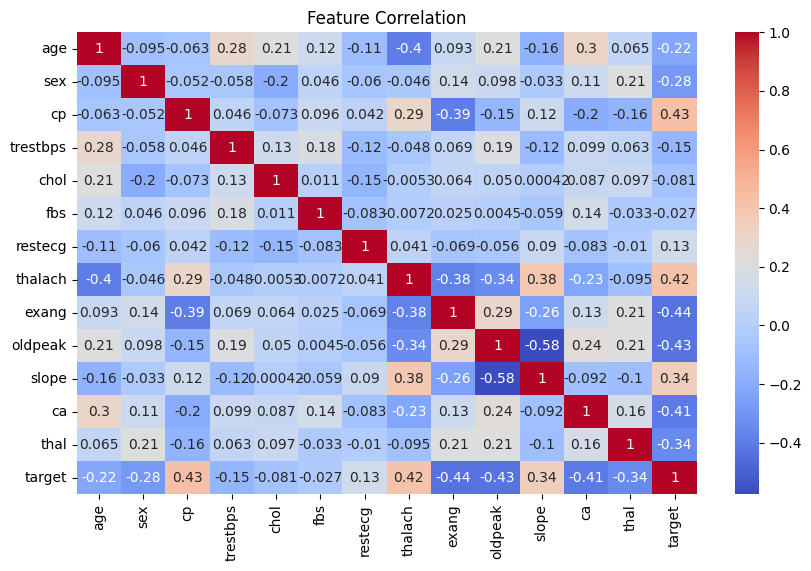

In [10]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True,cmap="coolwarm")
plt.title('Feature Correlation')
plt.show()

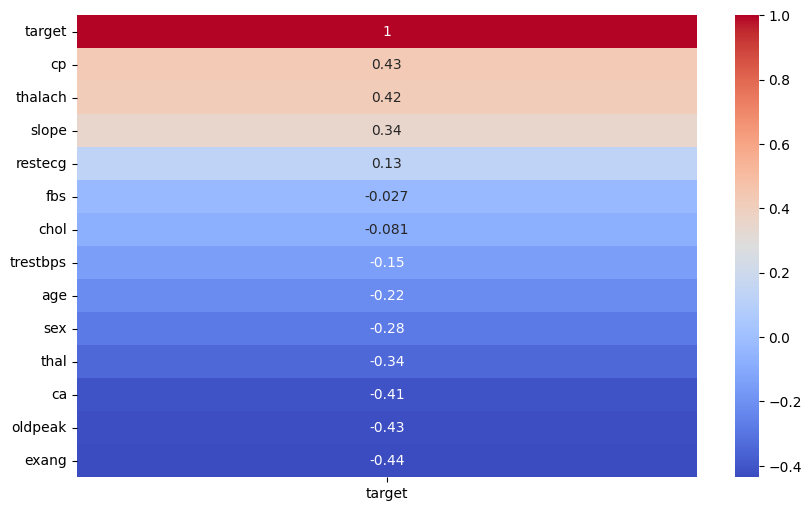

In [11]:
corr = df.corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr[['target']].sort_values(by='target', ascending=False), annot=True, cmap='coolwarm')
plt.show()

Detected the outliers and removed it

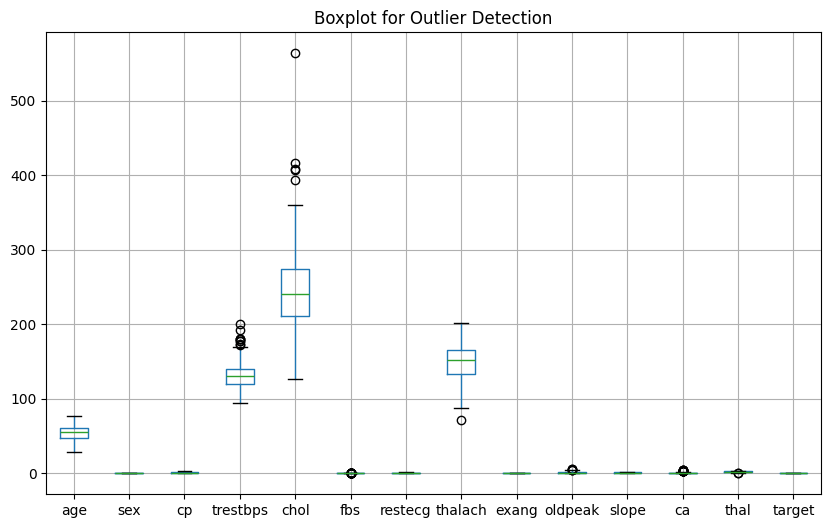

In [12]:
df.boxplot(figsize=(10, 6))
plt.title("Boxplot for Outlier Detection")
plt.show()

In [13]:
df_no_outliers = df[(np.abs(stats.zscore(df.select_dtypes(include=[float, int]))) < 3).all(axis=1)]

print("Original shape:", df.shape)
print("After removing outliers:", df_no_outliers.shape)

Original shape: (302, 14)
After removing outliers: (287, 14)


Check for class imbalance

In [14]:
churn_counts = df_no_outliers["target"].value_counts()
churn_rate = df_no_outliers["target"].value_counts(normalize=True)*100

print("target",churn_counts)
print("target_rate",churn_rate)

target target
1    158
0    129
Name: count, dtype: int64
target_rate target
1    55.052265
0    44.947735
Name: proportion, dtype: float64


In [15]:
x = df_no_outliers.drop("target",axis=1)
y = df_no_outliers["target"]

Splitted the data in the ratio of 60/20/20

In [16]:
X_train,X_temp,y_train,y_temp = train_test_split(x,y,test_size=0.4,random_state=42,stratify=y)
X_test,X_val,y_test,y_val = train_test_split(X_temp,y_temp,test_size=0.5,random_state=42,stratify=y_temp)

Standardize the columns

In [17]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_val_scaled = scaler.transform(X_val)

Implemented logistic regression

In [18]:
log_reg = LogisticRegression()
log_reg.fit(X_train_scaled,y_train)

LogisticRegression()

In [19]:
y_pred_log = log_reg.predict(X_test_scaled)
print(accuracy_score(y_test,y_pred_log))

0.7719298245614035


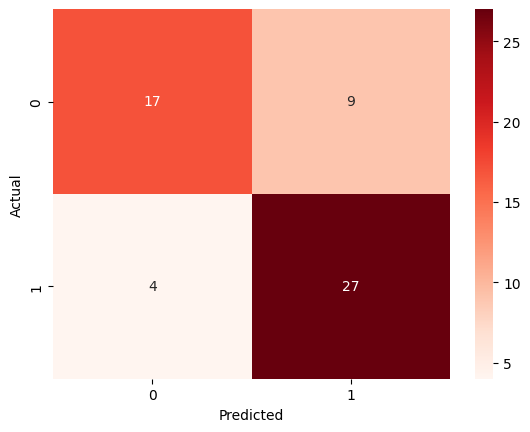

In [20]:
cm_log = confusion_matrix(y_test,y_pred_log)

sns.heatmap(cm_log,annot=True,fmt="d",cmap="Reds")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Implemented linear svm with different c value

In [21]:
c_vals = [0.001, 0.01, 0.1, 1, 10, 100]

best_model = None
best_acc = 0
best_c = None
for c in c_vals:
    svm_lr = LinearSVC(C=c,class_weight="balanced")
    svm_lr.fit(X_train_scaled,y_train)
    val_score = svm_lr.score(X_val_scaled,y_val)
    print(f"C={c} -> Validation Accuracy = {val_score}")
    if val_score>best_acc:
        best_model = svm_lr
        best_c = c
        best_acc = val_score
    
print("\n Best C for the model:",best_c)

C=0.001 -> Validation Accuracy = 0.8103448275862069
C=0.01 -> Validation Accuracy = 0.7758620689655172
C=0.1 -> Validation Accuracy = 0.7758620689655172
C=1 -> Validation Accuracy = 0.7758620689655172
C=10 -> Validation Accuracy = 0.7758620689655172
C=100 -> Validation Accuracy = 0.7758620689655172

 Best C for the model: 0.001


In [22]:
y_pred_svm = best_model.predict(X_test_scaled)
print("Accuracy score:",accuracy_score(y_test,y_pred_svm))
print("Precision:",precision_score(y_test,y_pred_svm))
print("Recall:",recall_score(y_test,y_pred_svm))
print("F1_score:",f1_score(y_test,y_pred_svm))

Accuracy score: 0.7719298245614035
Precision: 0.7647058823529411
Recall: 0.8387096774193549
F1_score: 0.8


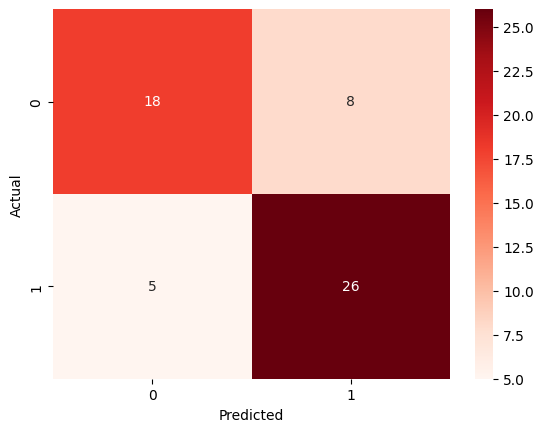

In [23]:
cm_svm = confusion_matrix(y_test,y_pred_svm)

sns.heatmap(cm_svm,annot=True,fmt="d",cmap="Reds")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Implemented SVM in RBF kernel by using gridsearch

In [24]:
param_grid = {
    "C": [0.001,0.1, 1, 10, 100],
    "gamma": [0.001, 0.01, 0.1, 1]
}

rbf_svm = SVC(kernel="rbf",class_weight="balanced")

grid = GridSearchCV(rbf_svm,
                    param_grid,
                    cv=5,
                    scoring='accuracy',
                    n_jobs=-1)

grid.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=SVC(class_weight='balanced'), n_jobs=-1,
             param_grid={'C': [0.001, 0.1, 1, 10, 100],
                         'gamma': [0.001, 0.01, 0.1, 1]},
             scoring='accuracy')

In [25]:
print("Best Parameters:", grid.best_params_)
print("Best Validation Accuracy:", grid.best_score_)

Best Parameters: {'C': 10, 'gamma': 0.01}
Best Validation Accuracy: 0.8717647058823529


In [26]:
best_model_rbf = grid.best_estimator_
y_pred_rbf = best_model_rbf.predict(X_test_scaled)

print("Accuracy rbf:",accuracy_score(y_test,y_pred_rbf))
print("precision rbf:",precision_score(y_test,y_pred_rbf))
print("Recall rbf:",recall_score(y_test,y_pred_rbf))
print("F1_score rbf:",f1_score(y_test,y_pred_rbf))

Accuracy rbf: 0.7894736842105263
precision rbf: 0.7714285714285715
Recall rbf: 0.8709677419354839
F1_score rbf: 0.8181818181818182


In [27]:
print("Classification Report:\n", classification_report(y_test, y_pred_rbf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rbf))

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.69      0.75        26
           1       0.77      0.87      0.82        31

    accuracy                           0.79        57
   macro avg       0.79      0.78      0.78        57
weighted avg       0.79      0.79      0.79        57

Confusion Matrix:
 [[18  8]
 [ 4 27]]


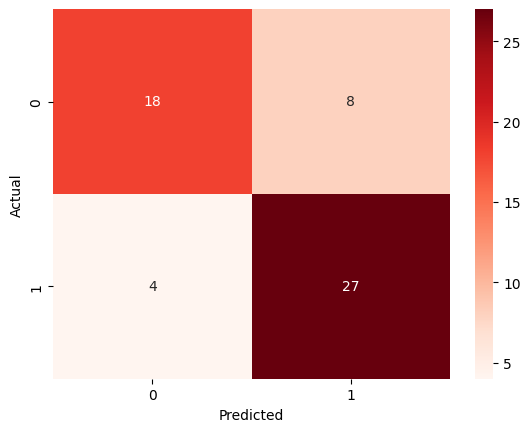

In [28]:
cm = confusion_matrix(y_test,y_pred_rbf)

sns.heatmap(cm,annot=True,fmt="d",cmap="Reds")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Compared all the models F1 score and found the best model

In [29]:
log_f1 = f1_score(y_test,y_pred_log)
lr_svm_f1 = f1_score(y_test,y_pred_svm)
rbf_f1 = f1_score(y_test,y_pred_rbf)

In [30]:
f1_scores = {
    "Logistic Regression": log_f1,
    "Linear SVM": lr_svm_f1,
    "RBF SVM": rbf_f1
}

best_model_name = max(f1_scores, key=f1_scores.get)
best_f1_value = f1_scores[best_model_name]

print("Model Performance (F1-score):")
for model, score in f1_scores.items():
    print(f"{model}: {score:.4f}")

print("\nBest Model:", best_model_name)
print("Best F1-score:", round(best_f1_value, 4))

Model Performance (F1-score):
Logistic Regression: 0.8060
Linear SVM: 0.8000
RBF SVM: 0.8182

Best Model: RBF SVM
Best F1-score: 0.8182


Calculated Sensitivity and Specificity

In [31]:
TN, FP, FN, TP = cm.ravel()

sensitivity = TP / (TP + FN)
specificity = TN / (TN + FP)

print("Sensitivity (Recall):", sensitivity)
print("Specificity:", specificity)

Sensitivity (Recall): 0.8709677419354839
Specificity: 0.6923076923076923


Plotted the precision and recall curve

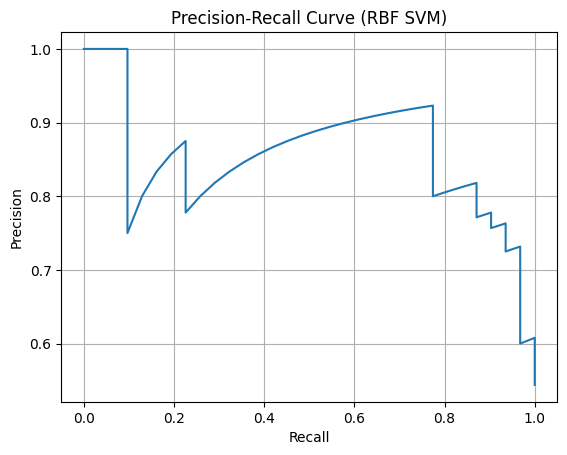

In [32]:
y_scores = best_model_rbf.decision_function(X_test_scaled)

precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (RBF SVM)")
plt.grid(True)
plt.show()

Found the optimal threshold 

In [33]:
best_f1 = 0
best_thresh = 0

for thresh in thresholds:
    preds = (y_scores >= thresh).astype(int)
    f1 = f1_score(y_test, preds)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = thresh

print("Best Threshold:", best_thresh)
print("Best F1-score:", best_f1)

Best Threshold: 0.5129969923307008
Best F1-score: 0.84375


In [34]:
custom_threshold = 0.5

y_pred_custom = (y_scores >= custom_threshold).astype(int)

print("Classification Report with Custom Threshold:")
print(classification_report(y_test, y_pred_custom))

Classification Report with Custom Threshold:
              precision    recall  f1-score   support

           0       0.83      0.77      0.80        26
           1       0.82      0.87      0.84        31

    accuracy                           0.82        57
   macro avg       0.83      0.82      0.82        57
weighted avg       0.83      0.82      0.82        57



Found the top 5 features using co efficient

In [35]:
feature_names = X_train.columns  

coefs = best_model.coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefs,
    "abs_coeff": np.abs(coefs)
})

top_5 = coef_df.sort_values("abs_coeff", ascending=False).head(5)
print(top_5)

    feature  coefficient  abs_coeff
11       ca    -0.089902   0.089902
8     exang    -0.084794   0.084794
7   thalach     0.083353   0.083353
2        cp     0.079631   0.079631
9   oldpeak    -0.064232   0.064232


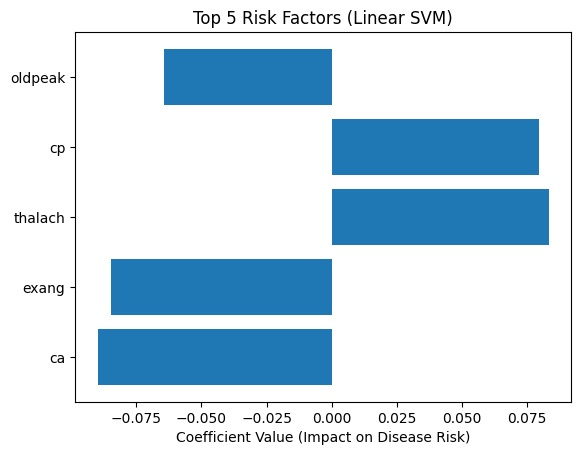

In [36]:
plt.barh(top_5['feature'], top_5['coefficient'])
plt.xlabel("Coefficient Value (Impact on Disease Risk)")
plt.title("Top 5 Risk Factors (Linear SVM)")
plt.show()

Predicted new value by 3 models

In [37]:
input = np.array([[52,1,0,125,212,0,1,168,0,1.0,2,2,3]])

my_input = pd.DataFrame(input,columns=X_train.columns)

my_input_scaled = scaler.transform(my_input)

best_models = {"Logistic_Regression":log_reg,"Linear_svm":best_model,"RBF_SVM":best_model_rbf}

for model_name, model in best_models.items():
    prediction = model.predict(my_input_scaled)
    print(f"{model_name} Prediction: {prediction[0]}")

Logistic_Regression Prediction: 0
Linear_svm Prediction: 0
RBF_SVM Prediction: 0


In [38]:
input = np.array([[58,0,0,100,248,0,0,122,0,1.0,1,0,2]])

my_input = pd.DataFrame(input,columns=X_train.columns)

my_input_scaled = scaler.transform(my_input)

best_models = {"Logistic_Regression":log_reg,"Linear_svm":best_model,"RBF_SVM":best_model_rbf}

for model_name, model in best_models.items():
    prediction = model.predict(my_input_scaled)
    print(f"{model_name} Prediction: {prediction[0]}")

Logistic_Regression Prediction: 1
Linear_svm Prediction: 1
RBF_SVM Prediction: 1
